<a href="https://colab.research.google.com/github/anathayna/tcc/blob/main/tcc_fim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="orange">**TCC: Identificação do discurso de ódio em memes**</font>

O Google Colab é uma plataforma baseada em Jupyter Notebook que oferece um ambiente de execução em nuvem com recursos gratuitos de GPU e TPU, amplamente utilizado em projetos de aprendizado de máquina e ciência de dados.

Este notebook documenta a etapa de pré-processamento do banco de dados do trabalho de conclusão de curso, cujo objetivo é identificar e classificar discursos de ódio em memes por meio de técnicas de aprendizado de máquina multimodal.

# <font color="orange">**Sumário**</font>

1.   Bibliotecas e dependências
2.   Banco de dados
3.   Treinamento
4.   Avaliação
5.   Conclusão

## <font color="orange">1. Bibliotecas e dependências</font>

In [1]:
!pip install -q jsonlines
!pip install -q transformers
!pip install -q torchmetrics
!pip install -q scikit-fuzzy
!pip install -q ftfy regex tqdm
!pip install -q pytorch-lightning
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q scikit-learn matplotlib seaborn pandas Pillow ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 55.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os
import clip
import json
import copy
import time
import torch
import random
import shutil
import zipfile
import numpy as np
import pandas as pd
import torch.nn as nn
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import torch.nn.functional as F

from PIL import Image
from google.colab import drive
from transformers import CLIPModel
from skfuzzy import control as ctrl
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPTokenizer
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.metrics import (roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay)

In [30]:
DATA_ROOT = "/content/drive/MyDrive/hateful_memes"

class Config:
    data_root        = DATA_ROOT
    image_size       = 224

    clip_model       = "openai/clip-vit-large-patch14"
    fusion           = "cross"

    map_dim          = 256
    num_map_layers   = 1
    num_pre_output   = 1
    drop_probs       = (0.1, 0.4, 0.2) # overfitting

    w_image_loss     = 1.0
    w_text_loss      = 1.0

    batch_size       = 16
    lr               = 1e-4
    weight_decay     = 1e-4
    max_epochs       = 20
    grad_clip        = 0.1
    seed             = 42

    output_dir       = "/content/outputs"
    device           = "cuda" if torch.cuda.is_available() else "cpu"

Config = Config()
os.makedirs(Config.output_dir, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(Config.seed)
print("⚙️ Configuração carregada:\n")

for key in dir(Config):
    if not key.startswith('__'):
        val = getattr(Config, key)
        print(f"   {key:<16}: {str(val):<30}")

⚙️ Configuração carregada:

   batch_size      : 16                            
   clip_model      : openai/clip-vit-large-patch14 
   data_root       : /content/drive/MyDrive/hateful_memes
   device          : cuda                          
   drop_probs      : (0.1, 0.4, 0.2)               
   fusion          : cross                         
   grad_clip       : 0.1                           
   image_size      : 224                           
   lr              : 0.0001                        
   map_dim         : 256                           
   max_epochs      : 20                            
   num_map_layers  : 1                             
   num_pre_output  : 1                             
   output_dir      : /content/outputs              
   seed            : 42                            
   w_image_loss    : 1.0                           
   w_text_loss     : 1.0                           
   weight_decay    : 0.0001                        


## <font color="orange">2. Banco de dados</font>

O banco de dados utilizado para a identificação do discurso de ódio em memes é o **Hateful Memes** disponibilizado pela Meta no *Challenge Hateful Memes*, um banco de dados com mais de **10 mil** imagens de memes em inglês, que contêm conteúdo ofensivo relacionado a gênero, raça, religião, orientação sexual, classe social e outros tópicos.

E o conjunto de dados é composto pelas seguintes porcentagens:

- **40%** de memes de ódio multimodal (multimodal hate): memes em que tanto o texto quanto a imagem contribuem para a mensagem de ódio.

- **10%** de memes de ódio unimodal (unimodal hate): memes em que apenas uma das modalidades (texto ou imagem) é suficiente para transmitir o discurso de ódio.

- **20%** de memes com confusão de texto benigna (benign text confounder): memes em que o texto foi alterado para remover o discurso de ódio, mas a imagem ainda pode sugerir um significado ofensivo.

- **20%** de memes com confusão de imagem benigna (benign image confounder): memes em que a imagem foi alterada para remover o discurso de ódio, mas o texto ainda pode sugerir um significado ofensivo.

- **10%** de memes não odiosos aleatórios (random non-hateful): memes que não contêm discurso de ódio, escolhidos aleatoriamente.


Um **confundidor benigno** é, basicamente, uma alteração mínima feita em um meme (seja mudando o texto ou a imagem) que faz com que a classificação dele mude de “odioso” para “não odioso”. A alteração é a menor possível, justamente para garantir que a diferença entre o meme odioso e o benigno seja bem sutil e dependa de uma análise genuína das duas modalidades (texto+imagem).


![](https://drivendata-public-assets.s3.amazonaws.com/memes-overview.png)


**Figura 1:** Exemplo de meme utilizado na competição  
Fonte: DRIVENDATA (2020)

In [4]:
#@markdown Defina o caminho para o arquivo **.zip** do banco de dados do *Hateful Memes*.
#@markdown **exemplo:** `"/content/drive/MyDrive/hateful_memes.zip"`

PATH_TO_ZIP_FILE = '/content/drive/MyDrive/hateful_memes.zip' #@param {type:"string"}

#@markdown Defina o diretório base para extrair o banco de dados.
#@markdown **exemplo:** `"/content"`

HOME = '/content' #@param {type:"string"}

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
os.chdir(HOME)
os.getcwd()
os.environ['PYTHONPATH'] += ":/content/model/"

In [7]:
zip_path = PATH_TO_ZIP_FILE
extract_path = '/content/model/'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [8]:
img_dir = '/content/model/hateful_memes/img'

image_extensions = ['.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp']

image_count = 0
for filename in os.listdir(img_dir):
    if any(filename.lower().endswith(ext) for ext in image_extensions):
        image_count += 1

print(f"total de imagens: {image_count}")

total de imagens: 12140


- Pasta `img/` — contém as imagens (formato .png) correspondentes aos memes.
- Arquivos `.jsonl`:
  - **train.jsonl** — conjunto de treinamento, com rótulos disponíveis (0 = non-hateful, 1 = hateful)
  - **dev_seen.jsonl** — conjunto de validação (seen)
  - **dev_unseen.jsonl** — conjunto de validação (unseen), sem rótulos
  - **test_seen.jsonl** — conjunto de teste (seen)
  - **test_unseen.jsonl** — conjunto de teste (unseen), sem rótulos


In [9]:
import jsonlines

base_path = '/content/model/hateful_memes/'

def read_jsonl_to_dataframe(jsonl_path):
    data = []
    with jsonlines.open(jsonl_path) as reader:
        for obj in reader:
            data.append(obj)
    return pd.DataFrame(data)

df_train = read_jsonl_to_dataframe(os.path.join(base_path, "train.jsonl"))
df_dev_seen = read_jsonl_to_dataframe(os.path.join(base_path, "dev_seen.jsonl"))
df_dev_unseen = read_jsonl_to_dataframe(os.path.join(base_path, "dev_unseen.jsonl"))
df_test_seen = read_jsonl_to_dataframe(os.path.join(base_path, "test_seen.jsonl"))
df_test_unseen = read_jsonl_to_dataframe(os.path.join(base_path, "test_unseen.jsonl"))

df_train.head()

,id,img,label,text
0,42953,img/42953.png,0,its their character not their color that matters
1,23058,img/23058.png,0,don't be afraid to love again everyone is not ...
2,13894,img/13894.png,0,putting bows on your pet
3,37408,img/37408.png,0,i love everything and everybody! except for sq...
4,82403,img/82403.png,0,"everybody loves chocolate chip cookies, even h..."


In [10]:
label_map = {0: 'non-hateful', 1: 'hateful'}

dfs = {
    'df_train': df_train,
    'df_dev_seen': df_dev_seen,
    'df_test_seen': df_test_seen,
    'df_dev_unseen': df_dev_unseen,
    'df_test_unseen': df_test_unseen
}

for name, df in dfs.items():
    if 'label' in df.columns:
        value_counts_df = df['label'].value_counts().reset_index()
        value_counts_df.columns = ['label', 'count']
        value_counts_df['%'] = (value_counts_df['count'] / value_counts_df['count'].sum() * 100).map('{:.2f}'.format)
        value_counts_df['meaning'] = value_counts_df['label'].map(label_map)
        display(value_counts_df.style.hide(axis='index').set_caption(f"{name} distribution"))

label,count,%,meaning
0,5481,64.48,non-hateful
1,3019,35.52,hateful


label,count,%,meaning
0,253,50.60,non-hateful
1,247,49.40,hateful


label,count,%,meaning
0,510,51.00,non-hateful
1,490,49.00,hateful


label,count,%,meaning
0,340,62.96,non-hateful
1,200,37.04,hateful


label,count,%,meaning
0,1250,62.50,non-hateful
1,750,37.50,hateful


In [11]:
labeled_dfs = [df_train, df_dev_seen, df_test_seen, df_dev_unseen, df_test_unseen]
df_total = pd.concat(labeled_dfs, ignore_index=True)

value_counts_total = df_total['label'].value_counts().reset_index()
value_counts_total.columns = ['label', 'count']
value_counts_total['%'] = (value_counts_total['count'] / value_counts_total['count'].sum() * 100).map('{:.2f}'.format)
value_counts_total['meaning'] = value_counts_total['label'].map(label_map)

print(f"Total de amostras com rótulo: {len(df_total)}\n")
display(value_counts_total.style.hide(axis='index').set_caption("Distribuição Total"))

Total de amostras com rótulo: 12540



label,count,%,meaning
0,7834,62.47,non-hateful
1,4706,37.53,hateful


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

📦 Dataset carregado

   train: 8,500 amostras
   dev_seen: 500 amostras
   test_seen: 1,000 amostras
   dev_unseen: 540 amostras
   test_unseen: 2,000 amostras



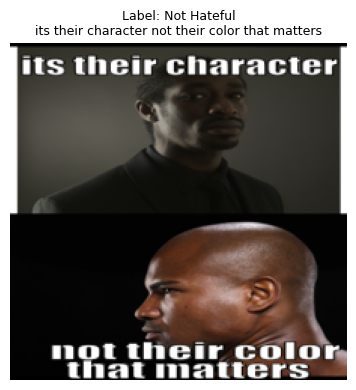

In [12]:
class HatefulMemesDataset(Dataset):
    def __init__(self, root, split="train", image_size=224):
        self.root       = root
        self.split      = split
        self.image_size = image_size

        jsonl_path = os.path.join(root, f"{split}.jsonl")
        with open(jsonl_path, "r") as f:
            self.samples = [json.loads(l) for l in f]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        img = Image.open(os.path.join(self.root, s["img"])).convert("RGB")
        img = img.resize((self.image_size, self.image_size))
        return {
            "image": img,
            "text" : s["text"],
            "label": int(s.get("label", 0)),
            "id"   : int(s["id"]),
        }


class HatefulMemesPrep:
    def __init__(self, clip_model_name):
        self.processor = CLIPProcessor.from_pretrained(clip_model_name)
        self.tokenizer = CLIPTokenizer.from_pretrained(clip_model_name)

    def __call__(self, batch):
        images  = [b["image"]  for b in batch]
        texts   = [b["text"]   for b in batch]
        labels  = torch.LongTensor([b["label"] for b in batch])
        ids     = [b["id"]     for b in batch]

        pv = self.processor(images=images, return_tensors="pt")["pixel_values"]
        tk = self.tokenizer(texts, padding=True, truncation=True,
                            max_length=77, return_tensors="pt")
        return {
            "pixel_values"  : pv,
            "input_ids"     : tk["input_ids"],
            "attention_mask": tk["attention_mask"],
            "labels"        : labels,
            "ids"           : ids,
        }


prep = HatefulMemesPrep(Config.clip_model)

data_root = base_path

ds_train = HatefulMemesDataset(data_root, "train", Config.image_size)
ds_dev_seen   = HatefulMemesDataset(data_root, "dev_seen", Config.image_size)
ds_test_seen  = HatefulMemesDataset(data_root, "test_seen",Config.image_size)
ds_dev_unseen   = HatefulMemesDataset(data_root, "dev_unseen", Config.image_size)
ds_test_unseen  = HatefulMemesDataset(data_root, "test_unseen",Config.image_size)

dl_train = DataLoader(ds_train, batch_size=Config.batch_size, shuffle=True,
                      num_workers=2, collate_fn=prep, pin_memory=True)
dl_dev_seen   = DataLoader(ds_dev_seen,   batch_size=Config.batch_size, shuffle=False,
                      num_workers=2, collate_fn=prep, pin_memory=True)
dl_test_seen  = DataLoader(ds_test_seen,  batch_size=Config.batch_size, shuffle=False,
                      num_workers=2, collate_fn=prep, pin_memory=True)
dl_dev_unseen   = DataLoader(ds_dev_unseen,   batch_size=Config.batch_size, shuffle=False,
                      num_workers=2, collate_fn=prep, pin_memory=True)
dl_test_unseen  = DataLoader(ds_test_unseen,  batch_size=Config.batch_size, shuffle=False,
                      num_workers=2, collate_fn=prep, pin_memory=True)

print(f"📦 Dataset carregado\n")
print(f"   train: {len(ds_train):,} amostras")
print(f"   dev_seen: {len(ds_dev_seen):,} amostras")
print(f"   test_seen: {len(ds_test_seen):,} amostras")
print(f"   dev_unseen: {len(ds_dev_unseen):,} amostras")
print(f"   test_unseen: {len(ds_test_unseen):,} amostras\n")

sample = ds_train[0]
plt.figure(figsize=(4,4))
plt.imshow(sample["image"])
plt.title(f"Label: {'Hateful' if sample['label']==1 else 'Not Hateful'}\n{sample['text'][:60]}",
          fontsize=9)
plt.axis("off")
plt.tight_layout()
plt.show()

## <font color="orange">3. Treinamento</font>

In [14]:
from typing import Tuple, Dict, Any

class HateCLIPper(nn.Module):
    """
      Hate-CLIPper: Kumar & Nandakumar (EMNLP 2022)
      Ref: https://github.com/gokulkarthik/hateclipper/blob/main/engine.py
      (reimplementação modificada)
    """
    def __init__(self, cfg: Any):
        super().__init__()
        self.fusion          = cfg.fusion
        self.map_dim         = cfg.map_dim
        self.w_image_loss    = cfg.w_image_loss
        self.w_text_loss     = cfg.w_text_loss
        drop                 = cfg.drop_probs

        _clip = CLIPModel.from_pretrained(cfg.clip_model)
        self.image_encoder = _clip.vision_model
        self.text_encoder  = _clip.text_model
        img_hidden = self.image_encoder.config.hidden_size
        txt_hidden = self.text_encoder.config.hidden_size
        del _clip

        for p in self.image_encoder.parameters(): p.requires_grad_(False)
        for p in self.text_encoder.parameters():  p.requires_grad_(False)

        self.image_map = self._build_map(img_hidden, cfg.map_dim, cfg.num_map_layers, drop[0])
        self.text_map  = self._build_map(txt_hidden, cfg.map_dim, cfg.num_map_layers, drop[0])

        if   self.fusion == "align":       fused_dim = cfg.map_dim
        elif self.fusion == "concat":      fused_dim = cfg.map_dim * 2
        elif self.fusion == "cross":       fused_dim = cfg.map_dim ** 2   # FIM
        elif self.fusion == "align_concat":fused_dim = cfg.map_dim * 3
        else: raise ValueError(f"Fusão desconhecida: {self.fusion}")

        self.pre_output = self._build_pre_output(fused_dim, cfg.map_dim,
                                                 cfg.num_pre_output, drop[1], drop[2])
        self.output = nn.Linear(cfg.map_dim, 1)

        if self.w_image_loss > 0:
            self.pre_output_image = self._build_pre_output(cfg.map_dim, cfg.map_dim,
                                                           cfg.num_pre_output, drop[1], drop[2])
            self.output_image = nn.Linear(cfg.map_dim, 1)

        if self.w_text_loss > 0:
            self.pre_output_text = self._build_pre_output(cfg.map_dim, cfg.map_dim,
                                                          cfg.num_pre_output, drop[1], drop[2])
            self.output_text = nn.Linear(cfg.map_dim, 1)

        self.criterion = nn.BCEWithLogitsLoss()

    @staticmethod
    def _build_map(in_dim: int, out_dim: int, n_layers: int, drop_p: float) -> nn.Sequential:
        layers = [nn.Linear(in_dim, out_dim), nn.Dropout(drop_p)]
        for _ in range(1, n_layers):
            layers += [nn.ReLU(), nn.Linear(out_dim, out_dim), nn.Dropout(drop_p)]
        return nn.Sequential(*layers)

    @staticmethod
    def _build_pre_output(in_dim: int, map_dim: int, n_layers: int, drop1: float, drop2: float) -> nn.Sequential:
        layers = [nn.Dropout(drop1)]
        if n_layers >= 1:
            layers += [nn.Linear(in_dim, map_dim), nn.ReLU(), nn.Dropout(drop2)]
        for _ in range(1, n_layers):
            layers += [nn.Linear(map_dim, map_dim), nn.ReLU(), nn.Dropout(drop2)]
        return nn.Sequential(*layers)

    def _fuse(self, v: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        if   self.fusion == "align":
            return torch.mul(v, t)
        elif self.fusion == "concat":
            return torch.cat([v, t], dim=1)
        elif self.fusion == "cross":
            fim = torch.bmm(v.unsqueeze(2), t.unsqueeze(1))
            return fim.reshape(fim.shape[0], -1)
        elif self.fusion == "align_concat":
            return torch.cat([torch.mul(v, t), v, t], dim=1)

    def forward(self, batch: Dict[str, torch.Tensor], return_features: bool = False) -> Tuple[torch.Tensor, ...]:
        v = self.image_encoder(pixel_values=batch["pixel_values"]).pooler_output
        v = F.normalize(self.image_map(v), p=2, dim=1)
        t = self.text_encoder(input_ids=batch["input_ids"],
                              attention_mask=batch["attention_mask"]).pooler_output
        t = F.normalize(self.text_map(t), p=2, dim=1)

        fused   = self._fuse(v, t)
        logit_m = self.output(self.pre_output(fused)).squeeze(1)
        prob_m  = torch.sigmoid(logit_m)

        logit_img = self.output_image(self.pre_output_image(v)).squeeze(1) \
                    if self.w_image_loss > 0 else None
        logit_txt = self.output_text(self.pre_output_text(t)).squeeze(1) \
                    if self.w_text_loss  > 0 else None

        if return_features:
            return prob_m, logit_m, logit_img, logit_txt, v, t

        return prob_m, logit_m, logit_img, logit_txt

    def compute_loss(self, batch: Dict[str, torch.Tensor]) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        prob_m, logit_m, logit_img, logit_txt = self(batch)
        y = batch["labels"].float()

        loss_m   = self.criterion(logit_m,   y)
        loss_img = self.criterion(logit_img, y) if logit_img is not None else 0.0
        loss_txt = self.criterion(logit_txt, y) if logit_txt is not None else 0.0

        total = loss_m + self.w_image_loss * loss_img + self.w_text_loss * loss_txt
        return total, loss_m, loss_img, loss_txt


model = HateCLIPper(Config).to(Config.device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n✅ Modelo criado: {n_params:,} parâmetros treináveis")
print(f"   Fusão: {Config.fusion}  |  map_dim: {Config.map_dim}")

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Modelo criado: 17,369,091 parâmetros treináveis
   Fusão: cross  |  map_dim: 256


In [15]:
drive_output_dir = "/content/drive/MyDrive/hateful_memes/outputs"
os.makedirs(drive_output_dir, exist_ok=True)
drive_ckpt_path = os.path.join(drive_output_dir, "best_model.pt")
drive_history_path = os.path.join(drive_output_dir, "history.json")

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=Config.lr, weight_decay=Config.weight_decay
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.max_epochs)

scaler = torch.amp.GradScaler('cuda')

history = {"train_loss": [], "val_loss": [], "val_auroc": [], "val_acc": []}

def evaluate(model: nn.Module, loader: DataLoader, device: str) -> dict:
    model.eval()
    all_probs, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}

            with torch.amp.autocast('cuda'):
                probs, logit_m, logit_img, logit_txt = model(batch)
                y = batch["labels"].float()
                loss = model.criterion(logit_m, y)

            total_loss += loss.item()
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds      = (all_probs >= 0.5).astype(int)
    return {
        "loss"  : total_loss / len(loader),
        "auroc" : roc_auc_score(all_labels, all_probs),
        "acc"   : accuracy_score(all_labels, preds),
        "f1"    : f1_score(all_labels, preds),
        "probs" : all_probs,
        "labels": all_labels,
    }

best_auroc     = 0.0
best_ckpt_path = os.path.join(Config.output_dir, "best_model.pt")
history_path   = os.path.join(Config.output_dir, "history.json")

if os.path.exists(drive_ckpt_path):
    print(f"✅ Modelo já treinado encontrado no Drive.\nCarregando pesos de: {drive_ckpt_path}")
    model.load_state_dict(torch.load(drive_ckpt_path, map_location=Config.device))
    shutil.copy(drive_ckpt_path, best_ckpt_path)
    if os.path.exists(drive_history_path):
        with open(drive_history_path, 'r') as f:
            history = json.load(f)
else:
    print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'Val AUROC':>10} {'Val Acc':>9} {'Tempo':>8}")
    print("─" * 65)

    for epoch in range(1, Config.max_epochs + 1):
        model.train()
        t0      = time.time()
        ep_loss = 0.0

        for batch in dl_train:
            batch = {k: v.to(Config.device) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                total_loss, *_ = model.compute_loss(batch)

            scaler.scale(total_loss).backward()

            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), Config.grad_clip)

            scaler.step(optimizer)
            scaler.update()

            ep_loss += total_loss.item()

        scheduler.step()

        train_loss = ep_loss / len(dl_train)
        val_metrics = evaluate(model, dl_dev_seen, Config.device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_auroc"].append(val_metrics["auroc"])
        history["val_acc"].append(val_metrics["acc"])

        elapsed = time.time() - t0
        print(f"{epoch:>6} {train_loss:>12.4f} {val_metrics['loss']:>10.4f} "
              f"{val_metrics['auroc']:>10.4f} {val_metrics['acc']:>9.4f} {elapsed:>7.1f}s")

        if val_metrics["auroc"] > best_auroc:
            best_auroc = val_metrics["auroc"]
            torch.save(model.state_dict(), best_ckpt_path)
            print(f"         ⭐ Melhor AUROC: {best_auroc:.4f} — checkpoint salvo")

    with open(history_path, 'w') as f:
        json.dump(history, f)

    print(f"\n✅ Treino concluído -- Melhor Val AUROC: {best_auroc:.4f}")

    shutil.copy(best_ckpt_path, drive_ckpt_path)
    shutil.copy(history_path, drive_history_path)
    print(f"✅ Modelo e histórico salvos com sucesso no Google Drive.\n{drive_ckpt_path}")

 Epoch   Train Loss   Val Loss  Val AUROC   Val Acc    Tempo
─────────────────────────────────────────────────────────────────
     1       1.7331     0.7338     0.7341    0.6220   122.6s
         ⭐ Melhor AUROC: 0.7341 — checkpoint salvo
     2       1.3984     0.7536     0.7483    0.6460   126.5s
         ⭐ Melhor AUROC: 0.7483 — checkpoint salvo
     3       1.2811     0.7587     0.7629    0.6560   126.4s
         ⭐ Melhor AUROC: 0.7629 — checkpoint salvo
     4       1.2165     0.7671     0.7667    0.6580   126.6s
         ⭐ Melhor AUROC: 0.7667 — checkpoint salvo
     5       1.1656     0.7052     0.7773    0.6720   126.3s
         ⭐ Melhor AUROC: 0.7773 — checkpoint salvo
     6       1.1164     0.8711     0.7779    0.6640   126.3s
         ⭐ Melhor AUROC: 0.7779 — checkpoint salvo
     7       1.0741     0.8628     0.7808    0.6740   126.7s
         ⭐ Melhor AUROC: 0.7808 — checkpoint salvo
     8       1.0282     0.7859     0.7901    0.6860   126.4s
         ⭐ Melhor AUROC: 0.7

## <font color="orange">4. Avaliação</font>

  RESULTADO FINAL — test_seen
  AUROC    : 0.8237
  Accuracy : 0.7390
  F1-Score : 0.6997


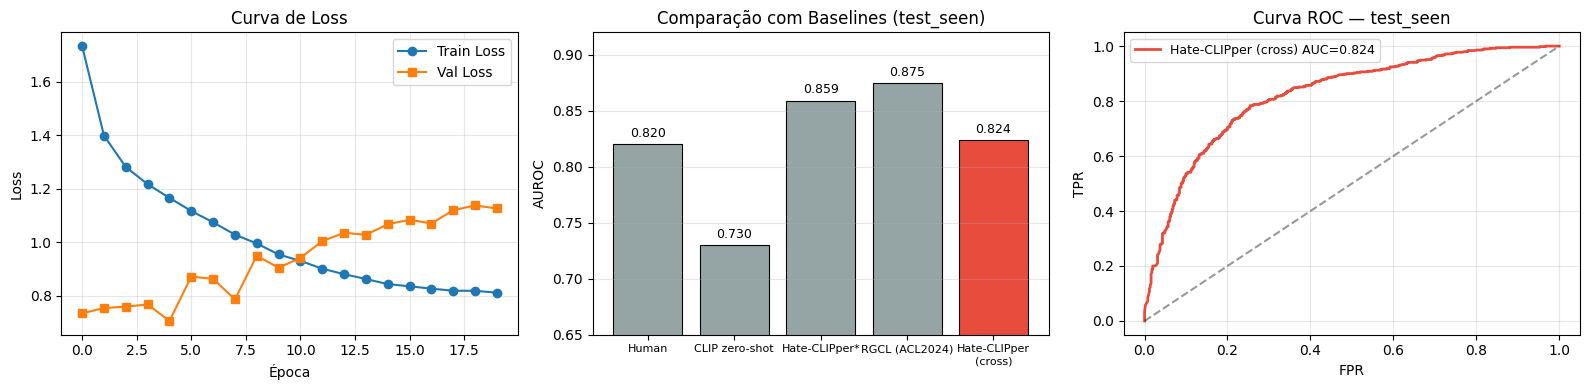


              precision    recall  f1-score   support

 Not Hateful       0.70      0.85      0.77       510
     Hateful       0.80      0.62      0.70       490

    accuracy                           0.74      1000
   macro avg       0.75      0.74      0.73      1000
weighted avg       0.75      0.74      0.74      1000



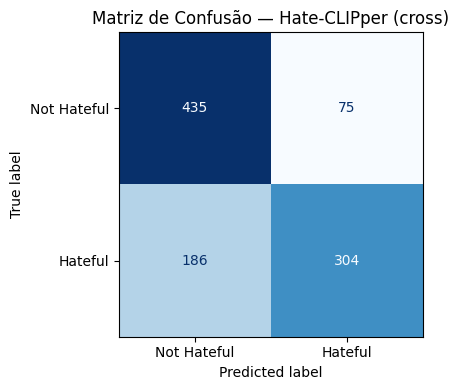

In [16]:
model.load_state_dict(torch.load(best_ckpt_path, map_location=Config.device, weights_only=True))
test_metrics = evaluate(model, dl_test_seen, Config.device)

print("=" * 50)
print("  RESULTADO FINAL — test_seen")
print("=" * 50)
print(f"  AUROC    : {test_metrics['auroc']:.4f}")
print(f"  Accuracy : {test_metrics['acc']:.4f}")
print(f"  F1-Score : {test_metrics['f1']:.4f}")
print("=" * 50)

BASELINES = {
    "Human"          : 0.820,
    "CLIP zero-shot" : 0.730,
    "Hate-CLIPper*"  : 0.859,
    "RGCL (ACL2024)" : 0.875,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
if history and history.get("train_loss"):
    ax.plot(history["train_loss"], label="Train Loss", marker="o")
    ax.plot(history["val_loss"],   label="Val Loss",   marker="s")
else:
    ax.text(0.5, 0.5, "Histórico não disponível", ha="center", va="center", fontsize=10)
ax.set_xlabel("Época"); ax.set_ylabel("Loss")
ax.set_title("Curva de Loss"); ax.legend(); ax.grid(True, alpha=0.3)


ax = axes[1]
names  = list(BASELINES.keys()) + [f"Hate-CLIPper\n({Config.fusion})"]
values = list(BASELINES.values()) + [test_metrics["auroc"]]
colors = ["#95a5a6"] * len(BASELINES) + ["#e74c3c"]
bars   = ax.bar(names, values, color=colors, edgecolor="black", linewidth=0.8)
ax.set_ylim(0.65, 0.92)
ax.set_ylabel("AUROC")
ax.set_title("Comparação com Baselines (test_seen)")
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.tick_params(axis="x", labelsize=8)
ax.grid(True, alpha=0.3, axis="y")


ax = axes[2]
fpr, tpr, _ = roc_curve(test_metrics["labels"], test_metrics["probs"])
ax.plot(fpr, tpr, color="#e74c3c", lw=2,
        label=f"Hate-CLIPper ({Config.fusion}) AUC={test_metrics['auroc']:.3f}")
ax.plot([0,1],[0,1], "k--", alpha=0.4)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Curva ROC — test_seen")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{Config.output_dir}/avaliacao_final.png", dpi=150)
plt.show()


print("\n" + classification_report(test_metrics["labels"],
                                   (test_metrics["probs"] >= 0.5).astype(int),
                                   target_names=["Not Hateful", "Hateful"]))
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(test_metrics["labels"],
                      (test_metrics["probs"] >= 0.5).astype(int))
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Hateful", "Hateful"])
disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
ax.set_title(f"Matriz de Confusão — Hate-CLIPper ({Config.fusion})")
plt.tight_layout()
plt.savefig(f"{Config.output_dir}/confusion_matrix.png", dpi=150)
plt.show()

In [17]:
model.load_state_dict(torch.load(best_ckpt_path, map_location=Config.device, weights_only=True))
model.eval()

all_score_multi, all_score_img, all_score_txt = [], [], []
all_labels_test, all_ids_test = [], []

with torch.no_grad():
    for batch in dl_test_seen:
        batch = {k: v.to(Config.device) if isinstance(v, torch.Tensor) else v
                 for k, v in batch.items()}

        with torch.amp.autocast('cuda'):
            probs_m, logit_m, logit_img, logit_txt = model(batch)

        all_score_multi.extend(probs_m.cpu().numpy())
        all_score_img.extend(torch.sigmoid(logit_img).cpu().numpy())
        all_score_txt.extend(torch.sigmoid(logit_txt).cpu().numpy())
        all_labels_test.extend(batch["labels"].cpu().numpy())
        all_ids_test.extend(batch["ids"])

scores_df = pd.DataFrame({
    "id"          : all_ids_test,
    "label"       : all_labels_test,
    "score_multi" : all_score_multi,
    "score_img"   : all_score_img,
    "score_txt"   : all_score_txt,
})
print(f"✅ Scores coletados: {len(scores_df)} amostras")
display(scores_df.head())

✅ Scores coletados: 1000 amostras


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,id,label,score_multi,score_img,score_txt
0,16395,1,0.996094,0.761719,0.719238
1,37405,1,0.008614,0.239746,0.363525
2,94180,1,0.998535,0.966309,0.875488
3,54321,1,0.384766,0.459961,0.108765
4,97015,1,0.991699,0.915527,0.653809


In [33]:
x_visual  = np.arange(0, 1.01, 0.01)
x_textual = np.arange(0, 1.01, 0.01)
x_hate    = np.arange(0, 101,  1.0)

visual_score  = ctrl.Antecedent(x_visual,  "visual_score")
textual_score = ctrl.Antecedent(x_textual, "textual_score")

hate_level = ctrl.Consequent(x_hate, "hate_level", defuzzify_method="centroid")

visual_score["baixo"] = fuzz.trimf(x_visual, [0.0, 0.0, 0.45])
visual_score["medio"] = fuzz.trimf(x_visual, [0.3, 0.5, 0.7])
visual_score["alto"]  = fuzz.trimf(x_visual, [0.55, 1.0, 1.0])

textual_score["baixo"] = fuzz.trimf(x_textual, [0.0, 0.0, 0.45])
textual_score["medio"] = fuzz.trimf(x_textual, [0.3, 0.5, 0.7])
textual_score["alto"]  = fuzz.trimf(x_textual, [0.55, 1.0, 1.0])

hate_level["inofensivo"]   = fuzz.trimf(x_hate, [0,   0,  20])
hate_level["questionavel"] = fuzz.trimf(x_hate, [10,  25,  40])
hate_level["moderado"] = fuzz.trimf(x_hate, [30,  50,  70])
hate_level["critico"]  = fuzz.trimf(x_hate, [60,  75,  90])
hate_level["extremo"]  = fuzz.trimf(x_hate, [80, 100, 100])

rules = [
    ctrl.Rule(visual_score["baixo"] & textual_score["baixo"], hate_level["inofensivo"]),
    ctrl.Rule(visual_score["alto"]  & textual_score["alto"],  hate_level["extremo"]),
    ctrl.Rule(visual_score["medio"] & textual_score["medio"], hate_level["moderado"]),

    ctrl.Rule(visual_score["baixo"] & textual_score["alto"],  hate_level["critico"]),
    ctrl.Rule(visual_score["alto"]  & textual_score["baixo"], hate_level["moderado"]),

    ctrl.Rule(visual_score["alto"]  & textual_score["medio"], hate_level["critico"]),
    ctrl.Rule(visual_score["medio"] & textual_score["alto"],  hate_level["critico"]),

    ctrl.Rule(visual_score["baixo"] & textual_score["medio"], hate_level["questionavel"]),
    ctrl.Rule(visual_score["medio"] & textual_score["baixo"], hate_level["questionavel"]),
]

hate_ctrl = ctrl.ControlSystem(rules)
hate_sim  = ctrl.ControlSystemSimulation(hate_ctrl)

def fuzzy_hate_score(vis_score: float, txt_score: float):
    """
    Retorna uma tupla contendo: (hate_level ∈ [0,100], rótulo linguístico).
    """
    hate_sim.input["visual_score"]  = float(np.clip(vis_score,  0.01, 0.99))
    hate_sim.input["textual_score"] = float(np.clip(txt_score,  0.01, 0.99))
    hate_sim.compute()
    level = hate_sim.output["hate_level"]

    if   level < 20: label = "Inofensivo"
    elif level < 40: label = "Questionável"
    elif level < 60: label = "Moderado"
    elif level < 80: label = "Crítico"
    else:            label = "Extremo"

    return level, label

if "fuzzy_score" in scores_df.columns:
    scores_df.drop(columns=["fuzzy_score", "fuzzy_label"], inplace=True, errors="ignore")

scores_df[["fuzzy_score", "fuzzy_label"]] = scores_df.apply(
    lambda r: fuzzy_hate_score(r["score_img"], r["score_txt"]),
    axis=1,
    result_type="expand"
)

print("✅ Sistema Fuzzy aplicado. Distribuição dos rótulos:")
print(scores_df["fuzzy_label"].value_counts())
display(scores_df.head(10))


✅ Sistema Fuzzy aplicado. Distribuição dos rótulos:
fuzzy_label
Inofensivo      482
Questionável    148
Moderado        136
Crítico         125
Extremo         109
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,id,label,score_multi,score_img,score_txt,conflict_type,pred_classic,pred_fuzzy,correct_classic,correct_fuzzy,fuzzy_score,fuzzy_label
0,16395,1,0.996094,0.761719,0.719238,Consenso,1,1,1,1,91.735262,Extremo
1,37405,1,0.008614,0.239746,0.363525,Consenso,0,0,0,0,20.853794,Questionável
2,94180,1,0.998535,0.966309,0.875488,Consenso,1,1,1,1,92.933556,Extremo
3,54321,1,0.384766,0.459961,0.108765,Visual > Texto,0,0,0,0,25.000000,Questionável
4,97015,1,0.991699,0.915527,0.653809,Visual > Texto,1,1,1,1,80.847930,Extremo
5,73506,1,0.982910,0.638184,0.256836,Visual > Texto,1,0,1,0,37.011606,Questionável
6,5429,1,0.401611,0.772461,0.435547,Visual > Texto,0,1,0,1,72.636445,Crítico
7,70691,0,0.002642,0.149902,0.070557,Consenso,0,0,1,1,7.221589,Inofensivo
8,69421,1,0.001305,0.027802,0.433838,Texto > Visual,0,0,0,0,24.457865,Questionável
9,50162,1,0.967285,0.661621,0.645508,Consenso,1,1,1,1,67.264231,Crítico


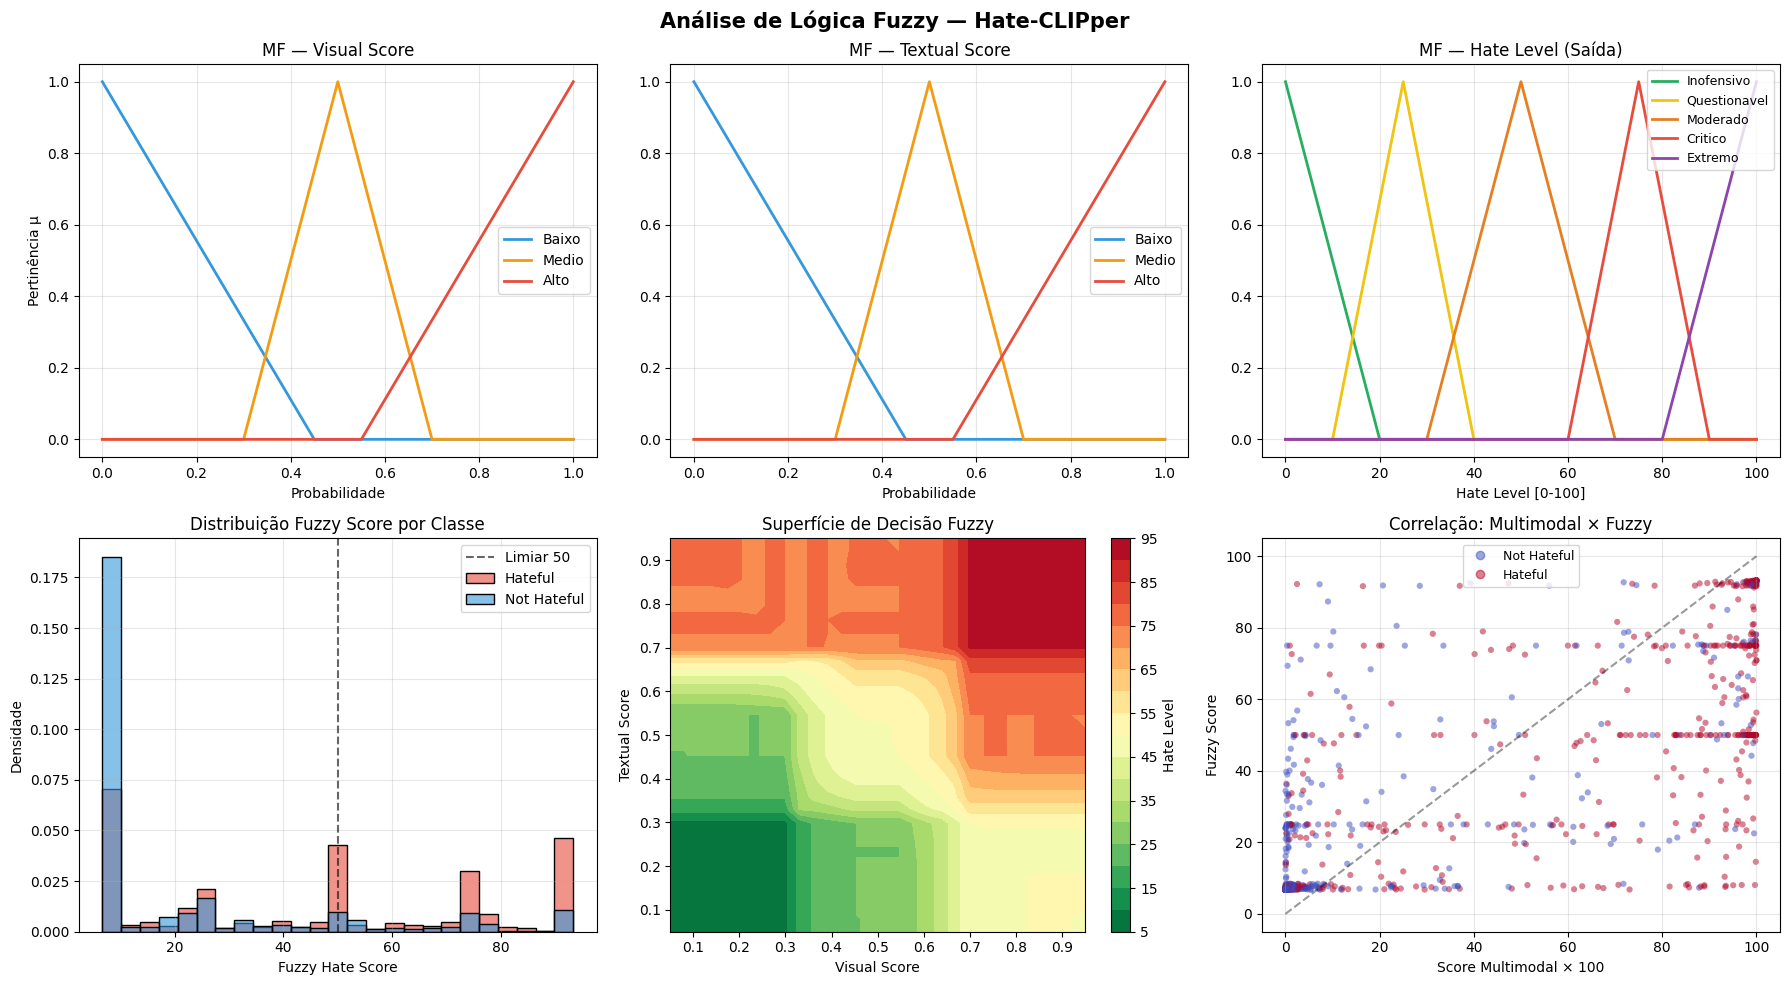

In [34]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Análise de Lógica Fuzzy — Hate-CLIPper", fontsize=15, fontweight="bold")

mf_configs = [
    (axes[0, 0], x_visual, visual_score, "MF — Visual Score", "Pertinência μ"),
    (axes[0, 1], x_textual, textual_score, "MF — Textual Score", "")
]

for ax, x_data, score_obj, title, ylabel in mf_configs:
    for name, color in zip(["baixo", "medio", "alto"], ["#3498db", "#f39c12", "#e74c3c"]):
        ax.plot(x_data, score_obj[name].mf, label=name.capitalize(), color=color, lw=2)
    ax.set_title(title)
    ax.set_xlabel("Probabilidade")
    if ylabel: ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

ax = axes[0, 2]
palette_hate = ["#27ae60", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]
for name, color in zip(["inofensivo", "questionavel", "moderado", "critico", "extremo"], palette_hate):
    ax.plot(x_hate, hate_level[name].mf, label=name.capitalize(), color=color, lw=2)
ax.set_title("MF — Hate Level (Saída)")
ax.set_xlabel("Hate Level [0-100]")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
sns.histplot(data=scores_df, x="fuzzy_score", hue="label", bins=25,
             palette=["#3498db", "#e74c3c"], stat="density", common_norm=False,
             alpha=0.6, ax=ax)
ax.axvline(50, color="k", linestyle="--", alpha=0.6, label="Limiar 50")
ax.set_title("Distribuição Fuzzy Score por Classe")
ax.set_xlabel("Fuzzy Hate Score")
ax.set_ylabel("Densidade")

ax.legend(["Limiar 50", "Hateful", "Not Hateful"])
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
grid_x = np.linspace(0.05, 0.95, 30)
grid_y = np.linspace(0.05, 0.95, 30)
Z = np.zeros((len(grid_y), len(grid_x)))
for i, gy in enumerate(grid_y):
    for j, gx in enumerate(grid_x):
        Z[i, j] = fuzzy_hate_score(gx, gy)[0]

im = ax.contourf(grid_x, grid_y, Z, levels=20, cmap="RdYlGn_r")
plt.colorbar(im, ax=ax, label="Hate Level")
ax.set_xlabel("Visual Score")
ax.set_ylabel("Textual Score")
ax.set_title("Superfície de Decisão Fuzzy")

ax = axes[1, 2]
scatter = ax.scatter(scores_df["score_multi"] * 100,
                     scores_df["fuzzy_score"],
                     c=scores_df["label"], cmap="coolwarm",
                     alpha=0.5, s=20, edgecolors="none")
ax.plot([0, 100], [0, 100], "k--", alpha=0.4, label="Diagonal")
ax.set_xlabel("Score Multimodal × 100")
ax.set_ylabel("Fuzzy Score")
ax.set_title("Correlação: Multimodal × Fuzzy")
handles, _ = scatter.legend_elements()
ax.legend(handles=handles, labels=["Not Hateful", "Hateful"], fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{Config.output_dir}/analise_fuzzy.png", dpi=150)
plt.show()


Amostras na zona de incerteza (score ∈ [0.35, 0.65]): 71

Distribuição do tipo de conflito (zona de incerteza):
conflict_type
Visual > Texto    31
Consenso          21
Texto > Visual    19
Name: count, dtype: int64


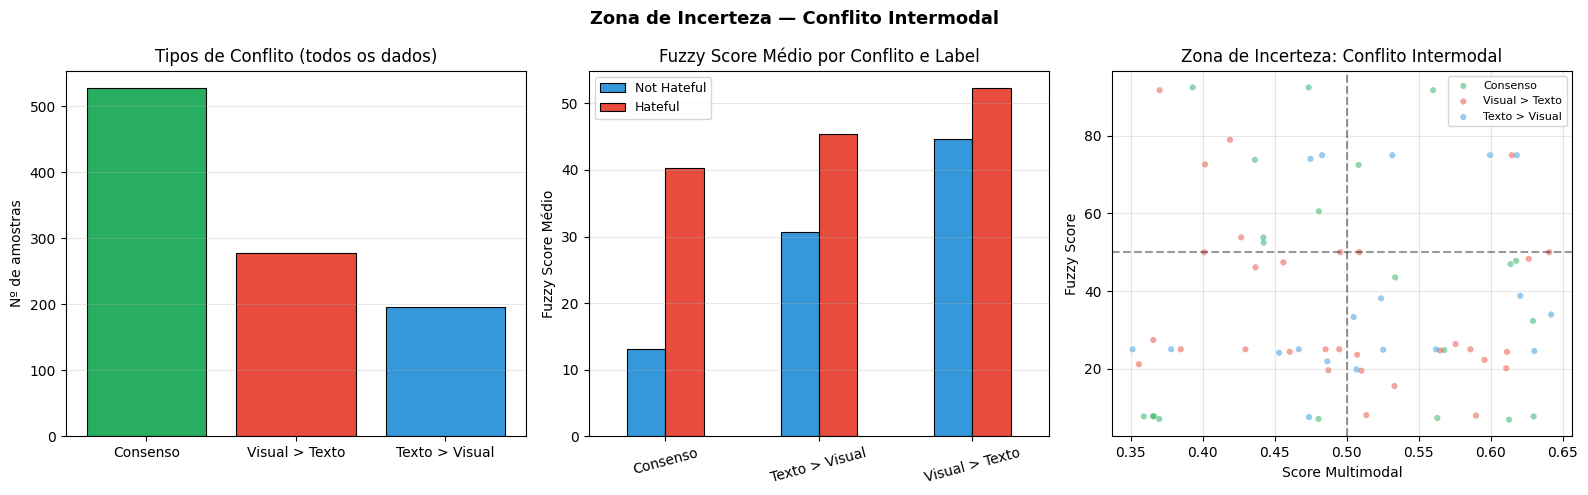


── Comparação de Decisão ──────────────────────────────
Método                      Accuracy         F1      AUROC
───────────────────────────────────────────────────────
Clássico (score≥0.5)          0.7390     0.6997     0.8237
Fuzzy (hate_level≥50)         0.6490     0.5551     0.7549


In [20]:
condicoes = [
    abs(scores_df["score_img"] - scores_df["score_txt"]) < 0.15,
    scores_df["score_img"] > scores_df["score_txt"]
]
escolhas = ["Consenso", "Visual > Texto"]
scores_df["conflict_type"] = np.select(condicoes, escolhas, default="Texto > Visual")

uncertain = scores_df[scores_df["score_multi"].between(0.35, 0.65)].copy()

print(f"Amostras na zona de incerteza (score ∈ [0.35, 0.65]): {len(uncertain)}")
print("\nDistribuição do tipo de conflito (zona de incerteza):")
print(uncertain["conflict_type"].value_counts())

color_map = {
    "Consenso": "#27ae60",
    "Visual > Texto": "#e74c3c",
    "Texto > Visual": "#3498db"
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Zona de Incerteza — Conflito Intermodal", fontsize=13, fontweight="bold")

ax = axes[0]
conflict_counts = scores_df["conflict_type"].value_counts()
cores_barras = [color_map[c] for c in conflict_counts.index]
ax.bar(conflict_counts.index, conflict_counts.values,
       color=cores_barras, edgecolor="black", linewidth=0.8)
ax.set_title("Tipos de Conflito (todos os dados)")
ax.set_ylabel("Nº de amostras")
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
pivot = scores_df.groupby(["conflict_type", "label"])["fuzzy_score"].mean().unstack()
pivot.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"],
           edgecolor="black", linewidth=0.8)
ax.set_title("Fuzzy Score Médio por Conflito e Label")
ax.set_xlabel("")
ax.set_ylabel("Fuzzy Score Médio")
ax.legend(["Not Hateful", "Hateful"], fontsize=9)
ax.tick_params(axis="x", rotation=15)
ax.grid(True, alpha=0.3, axis="y")

ax = axes[2]
for ctype, color in color_map.items():
    sub = uncertain[uncertain["conflict_type"] == ctype]
    ax.scatter(sub["score_multi"], sub["fuzzy_score"],
               c=color, label=ctype, alpha=0.5, s=20, edgecolors="none")
ax.axvline(0.5, color="k", linestyle="--", alpha=0.4)
ax.axhline(50, color="k", linestyle="--", alpha=0.4)
ax.set_xlabel("Score Multimodal")
ax.set_ylabel("Fuzzy Score")
ax.set_title("Zona de Incerteza: Conflito Intermodal")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{Config.output_dir}/zona_incerteza_fuzzy.png", dpi=150)
plt.show()

fuzzy_pred   = (scores_df["fuzzy_score"]  >= 50).astype(int)
classic_pred = (scores_df["score_multi"]  >= 0.5).astype(int)
y_true       = scores_df["label"]

print("\n── Comparação de Decisão ──────────────────────────────")
print(f"{'Método':<25} {'Accuracy':>10} {'F1':>10} {'AUROC':>10}")
print("─" * 55)
print(f"{'Clássico (score≥0.5)':<25} "
      f"{accuracy_score(y_true, classic_pred):>10.4f} "
      f"{f1_score(y_true, classic_pred):>10.4f} "
      f"{roc_auc_score(y_true, scores_df['score_multi']):>10.4f}")
print(f"{'Fuzzy (hate_level≥50)':<25} "
      f"{accuracy_score(y_true, fuzzy_pred):>10.4f} "
      f"{f1_score(y_true, fuzzy_pred):>10.4f} "
      f"{roc_auc_score(y_true, scores_df['fuzzy_score']/100):>10.4f}")


✅ Resultados de ablação encontrados no Drive. Carregando...


  TABELA DE ABLAÇÃO — Modos de Fusão (test_seen)
- Fusão -         Val AUROC  Test AUROC   Test Acc   Test F1
─────────────────────────────────────────────────────────────────
align                0.8048      0.8264     0.7380    0.6918
concat               0.7663      0.7929     0.6900    0.6247
cross                0.8146      0.8261     0.7430    0.7049
align_concat         0.7653      0.7915     0.6780    0.5872


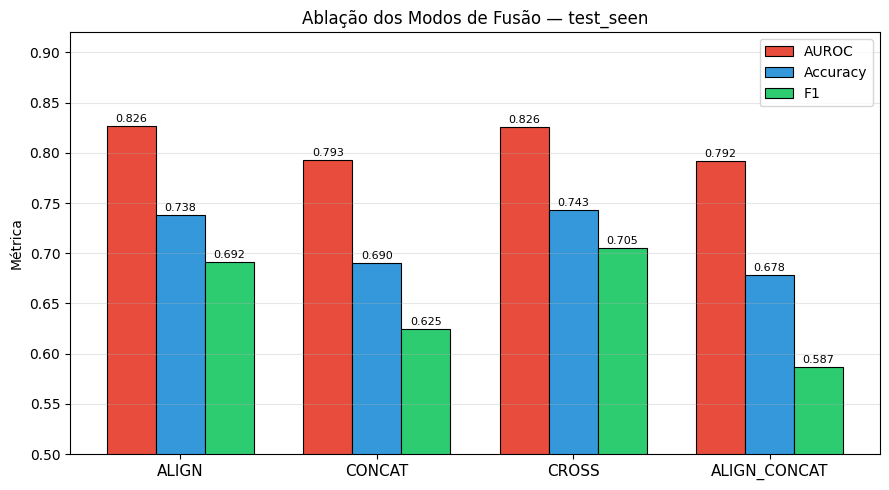

In [25]:
drive_output_dir = "/content/drive/MyDrive/hateful_memes/outputs"
os.makedirs(drive_output_dir, exist_ok=True)
ablation_results_path = os.path.join(drive_output_dir, "ablation_results.json")

if os.path.exists(ablation_results_path):
    print(f"✅ Resultados de ablação encontrados no Drive. Carregando...\n")
    with open(ablation_results_path, "r") as f:
        ablation_results = json.load(f)
else:
    ablation_results = {}
    FUSION_MODES = ["align", "concat", "cross", "align_concat"]

    for fusion_mode in FUSION_MODES:
        print(f"\n{'='*50}")
        print(f"  Treinando/Avaliando fusão: {fusion_mode.upper()}")
        print(f"{'='*50}")
        set_seed(Config.seed)

        tmp_cfg = copy.copy(Config)
        tmp_cfg.fusion = fusion_mode

        m = HateCLIPper(tmp_cfg).to(Config.device)
        opt = torch.optim.AdamW(
            [p for p in m.parameters() if p.requires_grad],
            lr=Config.lr, weight_decay=Config.weight_decay
        )
        scaler = torch.amp.GradScaler('cuda')

        best_val_auroc = 0.0
        ckpt = os.path.join(Config.output_dir, f"best_{fusion_mode}.pt")
        drive_ckpt = os.path.join(drive_output_dir, f"best_{fusion_mode}.pt")

        if os.path.exists(drive_ckpt):
            print(f"  ✅ Checkpoint para {fusion_mode.upper()} encontrado no Drive. Pulando treino...")
            m.load_state_dict(torch.load(drive_ckpt, map_location=Config.device, weights_only=True))
            shutil.copy(drive_ckpt, ckpt)
            val_m = evaluate(m, dl_dev_seen, Config.device)
            best_val_auroc = val_m["auroc"]
        else:
            for epoch in range(1, Config.max_epochs + 1):
                m.train()
                ep_loss = 0.0
                for batch in dl_train:
                    batch = {k: v.to(Config.device) if isinstance(v, torch.Tensor) else v
                             for k, v in batch.items()}
                    opt.zero_grad()

                    with torch.amp.autocast('cuda'):
                        total_loss, *_ = m.compute_loss(batch)

                    scaler.scale(total_loss).backward()
                    scaler.unscale_(opt)
                    nn.utils.clip_grad_norm_(m.parameters(), Config.grad_clip)

                    scaler.step(opt)
                    scaler.update()
                    ep_loss += total_loss.item()

                val_m = evaluate(m, dl_dev_seen, Config.device)
                print(f"  Ep {epoch}: train_loss={ep_loss/len(dl_train):.4f} "
                      f"val_auroc={val_m['auroc']:.4f}")

                if val_m["auroc"] > best_val_auroc:
                    best_val_auroc = val_m["auroc"]
                    torch.save(m.state_dict(), ckpt)

            print(f"  💾 Copiando {fusion_mode.upper()} para o Google Drive...")
            try:
                os.makedirs(drive_output_dir, exist_ok=True)
                shutil.copy(ckpt, drive_ckpt)
            except Exception as e:
                print(f"  ⚠️ Não foi possível salvar no Google Drive: {e}")
            m.load_state_dict(torch.load(ckpt, weights_only=True))

        test_m = evaluate(m, dl_test_seen, Config.device)
        ablation_results[fusion_mode] = {
            "val_auroc" : float(best_val_auroc),
            "test_auroc": float(test_m["auroc"]),
            "test_acc"  : float(test_m["acc"]),
            "test_f1"   : float(test_m["f1"]),
        }
        print(f"\n  ✅ {fusion_mode.upper()} — "
              f"Test AUROC: {test_m['auroc']:.4f} | "
              f"Acc: {test_m['acc']:.4f} | F1: {test_m['f1']:.4f}")
        del m
        torch.cuda.empty_cache()

    try:
        with open(ablation_results_path, "w") as f:
            json.dump(ablation_results, f, indent=4)
        print(f"\n✅ Resultados de ablação salvos no Drive em: {ablation_results_path}")
    except Exception as e:
        print(f"\n⚠️ Não foi possível salvar os resultados no Google Drive: {e}")

print("\n" + "="*65)
print("  TABELA DE ABLAÇÃO — Modos de Fusão (test_seen)")
print("="*65)
print(f"{'- Fusão -':<16} {'Val AUROC':>10} {'Test AUROC':>11} {'Test Acc':>10} {'Test F1':>9}")
print("─"*65)
for fusion_mode, res in ablation_results.items():
    print(f"{fusion_mode:<16} {res['val_auroc']:>10.4f} "
          f"{res['test_auroc']:>11.4f} {res['test_acc']:>10.4f} {res['test_f1']:>9.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
modes   = list(ablation_results.keys())
aurocs  = [ablation_results[m]["test_auroc"] for m in modes]
accs    = [ablation_results[m]["test_acc"]   for m in modes]
f1s     = [ablation_results[m]["test_f1"]    for m in modes]

x = np.arange(len(modes))
w = 0.25
ax.bar(x - w,   aurocs, w, label="AUROC",    color="#e74c3c", edgecolor="black", linewidth=0.8)
ax.bar(x,       accs,   w, label="Accuracy", color="#3498db", edgecolor="black", linewidth=0.8)
ax.bar(x + w,   f1s,    w, label="F1",       color="#2ecc71", edgecolor="black", linewidth=0.8)

for i, (a, c, f) in enumerate(zip(aurocs, accs, f1s)):
    ax.text(i - w, a + 0.002, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i,     c + 0.002, f"{c:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + w, f + 0.002, f"{f:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in modes], fontsize=11)
ax.set_ylim(0.50, 0.92); ax.set_ylabel("Métrica"); ax.legend()
ax.set_title("Ablação dos Modos de Fusão — test_seen")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{Config.output_dir}/ablacao_fusoes.png", dpi=150)
plt.show()


In [22]:
scores_df["pred_classic"] = (scores_df["score_multi"] >= 0.5).astype(int)
scores_df["pred_fuzzy"]   = (scores_df["fuzzy_score"]  >= 50).astype(int)
scores_df["correct_classic"] = (scores_df["pred_classic"] == scores_df["label"]).astype(int)
scores_df["correct_fuzzy"]   = (scores_df["pred_fuzzy"]   == scores_df["label"]).astype(int)

csv_path = os.path.join(Config.output_dir, "predictions_test.csv")
scores_df.to_csv(csv_path, index=False)
print(f"✅ Predições salvas em: {csv_path}")

report_path = os.path.join(Config.output_dir, "relatorio_tcc.txt")
with open(report_path, "w") as f:
    f.write("=" * 60 + "\n")
    f.write("  RESULTADOS — TCC: Discurso de Ódio em Memes\n")
    f.write("  Hate-CLIPper + Lógica Fuzzy\n")
    f.write("=" * 60 + "\n\n")

    f.write(f"Modelo CLIP  : {Config.clip_model}\n")
    f.write(f"Fusão        : {Config.fusion}\n")
    f.write(f"Dataset      : Hateful Memes Challenge (Facebook AI)\n\n")

    f.write("── Resultado Principal (test_seen) ─────────────────\n")
    f.write(f"  AUROC    : {test_metrics['auroc']:.4f}\n")
    f.write(f"  Accuracy : {test_metrics['acc']:.4f}\n")
    f.write(f"  F1-Score : {test_metrics['f1']:.4f}\n\n")

    f.write("── Ablação de Fusões (test_seen) ───────────────────\n")
    for mode, res in ablation_results.items():
        f.write(f"  {mode:<16}: AUROC={res['test_auroc']:.4f}  "
                f"Acc={res['test_acc']:.4f}  F1={res['test_f1']:.4f}\n")

    f.write("\n── Análise Fuzzy ───────────────────────────────────\n")
    f.write(f"  Decisão clássica — Acc: "
            f"{accuracy_score(scores_df['label'], scores_df['pred_classic']):.4f}  "
            f"F1: {f1_score(scores_df['label'], scores_df['pred_classic']):.4f}\n")
    f.write(f"  Decisão fuzzy    — Acc: "
            f"{accuracy_score(scores_df['label'], scores_df['pred_fuzzy']):.4f}  "
            f"F1: {f1_score(scores_df['label'], scores_df['pred_fuzzy']):.4f}\n")

    f.write("\n── Comparação com Literatura ───────────────────────\n")
    for name, auroc in BASELINES.items():
        f.write(f"  {name:<20}: AUROC = {auroc:.3f}\n")
    f.write(f"  {'Este trabalho':<20}: AUROC = {test_metrics['auroc']:.3f}\n")

print(f"✅ Relatório salvo em: {report_path}")

try:
    dest = f"/content/drive/MyDrive/hateful_memes/outputs"
    shutil.copytree(Config.output_dir, dest, dirs_exist_ok=True)
    print(f"✅ Resultados copiados para o Drive: {dest}")
except Exception as e:
    print(f"ℹ️  Drive não montado ({e}). Resultados em: {Config.output_dir}")


✅ Predições salvas em: /content/outputs/predictions_test.csv
✅ Relatório salvo em: /content/outputs/relatorio_tcc.txt
✅ Resultados copiados para o Drive: /content/drive/MyDrive/hateful_memes/outputs


## <font color="orange">5. Conclusão</font>

## <font color="orange">Teste</font>

In [23]:
!pip install --upgrade google-cloud-vision -q
!pip install deep-translator -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.2/543.2 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.5 MB/s eta 0:00:00


In [40]:
import io
import tempfile
import gradio as gr
from google.cloud import vision
from google.colab import userdata
from deep_translator import GoogleTranslator

gr.close_all()

try:
    key_json = userdata.get('GOOGLE_CLOUD_KEY')
    if key_json:
        with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
            f.write(key_json)
            os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = f.name
except Exception as e:
    print("Aviso: Chave GOOGLE_CLOUD_KEY não encontrada nos Secrets do Colab.", e)

try:
    vision_client = vision.ImageAnnotatorClient()
except Exception as e:
    print("Aviso: Falha ao inicializar o Vision API. Verifique suas credenciais.", e)
    vision_client = None

def classify_meme(image):
    if image is None:
        return "Nenhuma imagem fornecida.", "", "Por favor, faça o upload de uma imagem."

    text = ""
    if vision_client:
        try:
            byte_array = io.BytesIO()
            image.save(byte_array, format='PNG')
            content = byte_array.getvalue()
            vision_image = vision.Image(content=content)

            response = vision_client.text_detection(image=vision_image)
            texts = response.text_annotations

            if response.error.message:
                print(f"Erro na API Vision (Resposta): {response.error.message}")
            elif texts:
                text = texts[0].description.replace('\n', ' ').strip()
        except Exception as e:
            print(f"Erro na API Vision (Exceção): {e}")
            text = ""

    if not text:
        text = "no text"
        texto_traduzido = "sem texto"
    else:
        try:
            texto_traduzido = GoogleTranslator(source='auto', target='pt').translate(text)
        except Exception as e:
            texto_traduzido = "erro na tradução"

    model.eval()
    with torch.no_grad():
        batch_raw = [{"image": image.resize((Config.image_size, Config.image_size)), "text": text, "label": 0, "id": 0}]
        batch = prep(batch_raw)
        batch = {k: v.to(Config.device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

        probs_m, logit_m, logit_img, logit_txt = model(batch)

        prob_odio = probs_m.item()
        prob_img = torch.sigmoid(logit_img).item()
        prob_txt = torch.sigmoid(logit_txt).item()


    hate_level, categoria = fuzzy_hate_score(prob_img, prob_txt)

    resultado = (
        f"### 🚨 Análise Concluída\n\n"
        f"- **Score Multimodal:** {prob_odio*100:.2f}%\n"
        f"- **Score Visual:** {prob_img*100:.2f}%\n"
        f"- **Score Textual:** {prob_txt*100:.2f}%\n\n"
        f"**📌 Classificação Fuzzy:** {categoria} (Hate Level: {hate_level:.1f}/100)"
    )
    return text, texto_traduzido, resultado

def load_random_meme():
    row = scores_df.sample(1).iloc[0]
    img_id = str(int(row['id'])).zfill(5)
    img_path = os.path.join(base_path, 'img', f"{img_id}.png")

    try:
        img = Image.open(img_path).convert('RGB')
    except Exception:
        img = Image.new('RGB', (224, 224), color='white')

    try:
        texto = df_test_seen[df_test_seen['id'].astype(int) == int(row['id'])]['text'].values[0]
    except Exception:
        texto = "texto não encontrado"

    try:
        texto_traduzido = GoogleTranslator(source='auto', target='pt').translate(texto)
    except Exception:
        texto_traduzido = "erro na tradução"

    md_traducao = f"**Tradução do Meme:** {texto_traduzido}"

    row_dict = row.to_dict()
    row_dict['text'] = texto

    return img, row_dict, "", None, md_traducao

def check_guess(guess, row_data):
    if not row_data:
        return "⚠️ Por favor, clique em 'Carregar Meme Aleatório' primeiro."
    if not guess:
        return "⚠️ Por favor, selecione um palpite antes de verificar."

    real_label = "Ódio" if row_data['label'] == 1 else "Não Ódio"
    modelo_fuzzy = row_data['fuzzy_label']
    hate_level = row_data['fuzzy_score']
    prob_odio = row_data['score_multi'] * 100
    prob_img = row_data['score_img'] * 100
    prob_txt = row_data['score_txt'] * 100
    conflito = row_data.get('conflict_type', 'Desconhecido')

    md = f"### 🎯 Resultado da Verificação\n\n"
    md += f"- **Seu Palpite:** {guess}\n"
    md += f"- **Rótulo Real:** {real_label}\n"
    md += f"\n### 📊 Detalhes da Previsão do Modelo\n"
    md += f"- **Classificação Fuzzy:** {modelo_fuzzy} (Hate Level: {hate_level:.1f}/100)\n"
    md += f"- **Score Multimodal:** {prob_odio:.2f}%\n"
    md += f"- **Score Visual:** {prob_img:.2f}%\n"
    md += f"- **Score Textual:** {prob_txt:.2f}%\n"

    return md

with gr.Blocks(title="TCC: Discurso de Ódio em Memes") as demo:
    gr.Markdown("# TCC: Identificador de Discurso de Ódio em Memes")

    with gr.Tab("Upload de Meme"):
        gr.Markdown("Faça o upload de um meme. O sistema usará IA para extrair o texto automaticamente, traduzi-lo e classificar se contém discurso de ódio usando lógica Fuzzy.")
        with gr.Row():
            with gr.Column():
                img_input = gr.Image(type="pil", label="Faça o Upload do Meme")
                btn_classify = gr.Button("Classificar Meme", variant="primary")
            with gr.Column():
                txt_en = gr.Textbox(label="Texto Extraído (Inglês)")
                txt_pt = gr.Textbox(label="Texto Traduzido (Português)")
                md_result = gr.Markdown(label="Resultado da Análise")

        btn_classify.click(classify_meme, inputs=[img_input], outputs=[txt_en, txt_pt, md_result])

    with gr.Tab("Teste o Modelo (Aleatório)"):
        gr.Markdown("Sorteie um meme do banco de dados, dê o seu palpite e veja se você concorda com o Modelo e com a classificação real!")
        state_meme = gr.State()
        with gr.Row():
            with gr.Column():
                img_random = gr.Image(type="pil", label="Meme Aleatório", interactive=False)
                md_translation = gr.Markdown()
                btn_new_meme = gr.Button("Carregar Novo Meme Aleatório")
            with gr.Column():
                radio_guess = gr.Radio(
                    choices=["Inofensivo", "Questionável", "Moderado", "Crítico", "Extremo"],
                    label="O que você acha que é?"
                )
                btn_verify = gr.Button("Verificar Resultado", variant="primary")
                md_verify_result = gr.Markdown()

        btn_new_meme.click(load_random_meme, inputs=[], outputs=[img_random, state_meme, md_verify_result, radio_guess, md_translation])
        btn_verify.click(check_guess, inputs=[radio_guess, state_meme], outputs=[md_verify_result])

demo.launch(debug=True, share=True)


Closing server running on port: 7860
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://227e920d624616b180.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://227e920d624616b180.gradio.live
